In [1]:
import pandas as pd
import sqlite3
import os

#get the path and the tables
file_table_map = {
    "Big_Cities_Health_Data_Inventory_cleaned.csv": "big_cities_health_data",
    "us_colleges_clean.csv": "us_colleges",
    "Top_20_metros_cleaned.csv": "top_20_metros"
}

In [3]:
#connect to the DB that I created
conn = sqlite3.connect("final.db")

In [5]:
#import the CSV files
csv_files = [
    'Big_Cities_Health_Data_Inventory_cleaned.csv',
    'us_colleges_clean.csv',
    'Top_20_metros_cleaned.csv'
]

In [7]:
for csv_file in csv_files:
    if not os.path.exists(csv_file):
        print(f"File not found: {csv_file}")
        continue
    table_name = os.path.splitext(os.path.basename(csv_file))[0]
    df = pd.read_csv(csv_file)
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f"Added {csv_file} to table '{table_name}' in final.db.")

conn.close()

Added Big_Cities_Health_Data_Inventory_cleaned.csv to table 'Big_Cities_Health_Data_Inventory_cleaned' in final.db.
Added us_colleges_clean.csv to table 'us_colleges_clean' in final.db.
Added Top_20_metros_cleaned.csv to table 'Top_20_metros_cleaned' in final.db.


In [9]:
conn = sqlite3.connect("final.db")

for filename, table in file_table_map.items():
    if filename.endswith(".csv"):
        df = pd.read_csv(filename)
    else:
        raise ValueError(f"Unsupported file type: {filename}")
    df.to_sql(table, conn, if_exists="replace", index=False)
    print(f"Loaded {filename} into table '{table}'.")

Loaded Big_Cities_Health_Data_Inventory_cleaned.csv into table 'big_cities_health_data'.
Loaded us_colleges_clean.csv into table 'us_colleges'.
Loaded Top_20_metros_cleaned.csv into table 'top_20_metros'.


In [11]:
#display the tables. 
#I have ran this too many times and it added the tables multiple times
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables:", tables['name'].tolist())

Tables: ['Big_Cities_Health_Data_Inventory_cleaned', 'us_colleges_clean', 'Top_20_metros_cleaned', 'big_cities_health_data', 'us_colleges', 'top_20_metros']


In [13]:
#check the column names, so I can see if I can join 
conn = sqlite3.connect("final.db")
cursor = conn.execute("PRAGMA table_info(big_cities_health_data);")
for row in cursor:
    print(row)
conn.close()

(0, 'Indicator_Category', 'TEXT', 0, None, 0)
(1, 'Indicator', 'TEXT', 0, None, 0)
(2, 'Year', 'TEXT', 0, None, 0)
(3, 'Gender', 'TEXT', 0, None, 0)
(4, 'Race_Ethnicity', 'TEXT', 0, None, 0)
(5, 'Value', 'TEXT', 0, None, 0)
(6, 'Place', 'TEXT', 0, None, 0)
(7, 'BCHC_Requested_Methodology', 'TEXT', 0, None, 0)
(8, 'Source', 'TEXT', 0, None, 0)
(9, 'Unnamed: 9', 'TEXT', 0, None, 0)
(10, 'Unnamed: 10', 'TEXT', 0, None, 0)


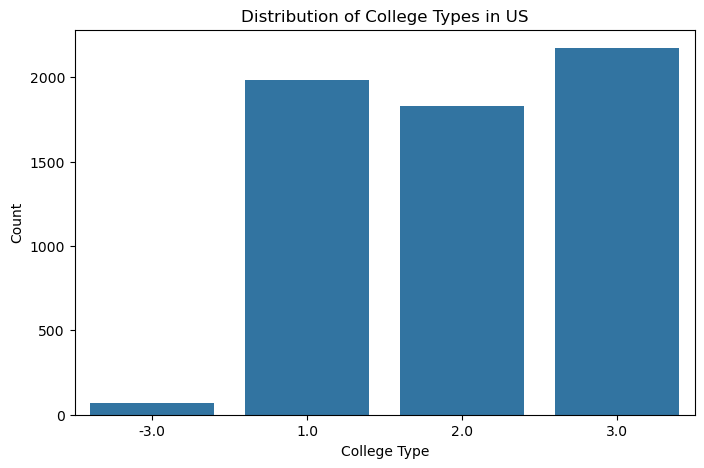

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

#looking at college type and number per type

conn = sqlite3.connect("final.db")
df = pd.read_sql_query("SELECT TYPE FROM us_colleges", conn)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="TYPE")
plt.title("Distribution of College Types in US")
plt.xlabel("College Type")
plt.ylabel("Count")
plt.show()
conn.close()

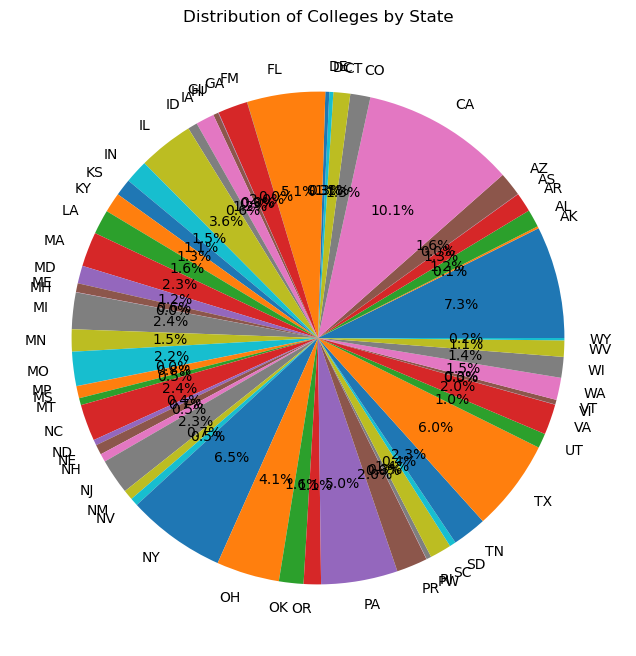

In [35]:
#looking just at the colleges by state, using a pie chart

conn = sqlite3.connect("final.db")
df2 = pd.read_sql_query("SELECT State, COUNT(*) as CollegeCount FROM us_colleges GROUP BY State", conn)
plt.figure(figsize=(8,8))
plt.pie(df2['CollegeCount'], labels=df2['STATE'], autopct='%1.1f%%')
plt.title('Distribution of Colleges by State')
plt.savefig('viz2_colleges_by_state.png')
plt.show()
plt.close()

C:\Users\hessk\AppData\Local\Temp\ipykernel_18400\2070600244.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="score", y="metro", palette="viridis")


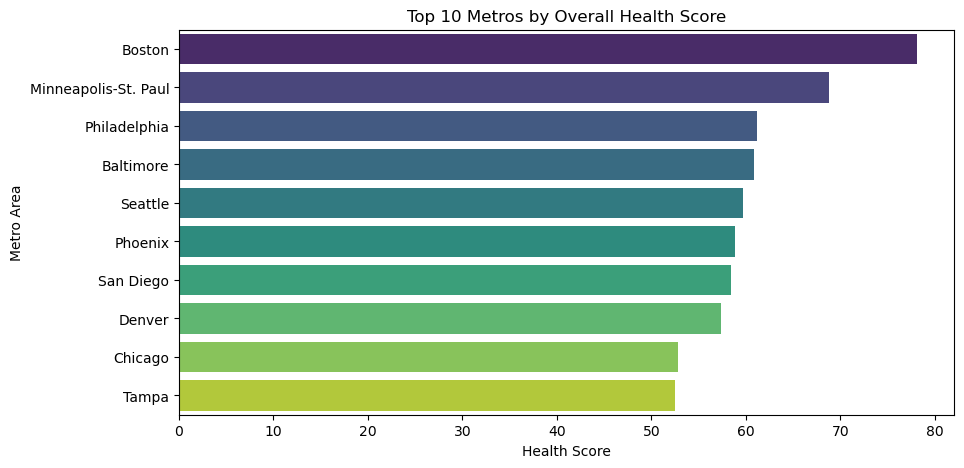

In [43]:
#using metros and health

conn = sqlite3.connect("final.db")
df = pd.read_sql_query("SELECT metro, score FROM top_20_metros ORDER BY score DESC LIMIT 10", conn)
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="score", y="metro", palette="viridis")
plt.title("Top 10 Metros by Overall Health Score")
plt.xlabel("Health Score")
plt.ylabel("Metro Area")
plt.show()
conn.close()

C:\Users\hessk\AppData\Local\Temp\ipykernel_18400\1996185825.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="college_count", y="metro", palette="crest")


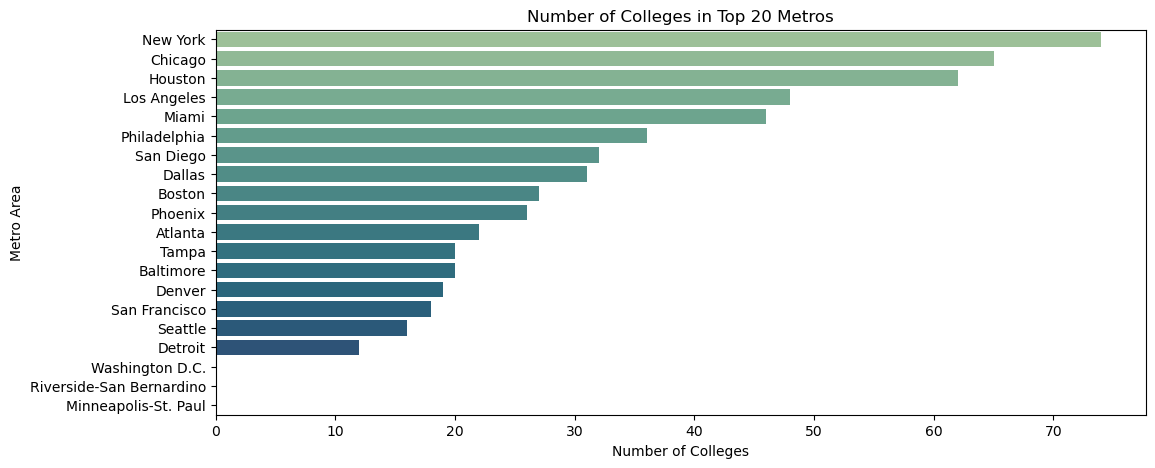

In [41]:
#using both colleges and metros

query = """
SELECT
    m.metro,
    COUNT(c.NAME) as college_count
FROM
    top_20_metros m
LEFT JOIN
    us_colleges c
ON
    c.CITY LIKE '%' || m.metro || '%'
GROUP BY
    m.metro
ORDER BY
    college_count DESC
"""
conn = sqlite3.connect("final.db")
df = pd.read_sql_query(query, conn)
plt.figure(figsize=(12,5))
sns.barplot(data=df, x="college_count", y="metro", palette="crest")
plt.title("Number of Colleges in Top 20 Metros")
plt.xlabel("Number of Colleges")
plt.ylabel("Metro Area")
plt.show()
conn.close()

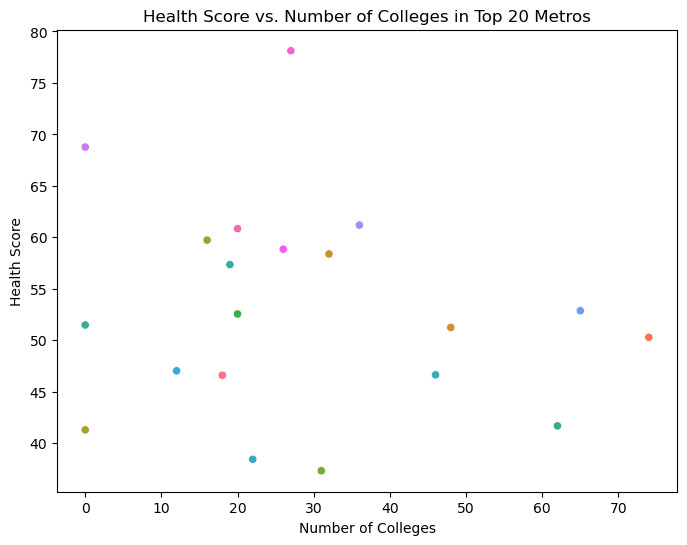

In [45]:
#attempting to combine all 3 tables

query = """
WITH college_counts AS (
    SELECT
        m.metro,
        COUNT(c.NAME) as college_count
    FROM
        top_20_metros m
    LEFT JOIN
        us_colleges c
    ON
        c.CITY LIKE '%' || m.metro || '%'
    GROUP BY m.metro
)
SELECT
    m.metro,
    m.score,
    cc.college_count
FROM
    top_20_metros m
JOIN
    college_counts cc ON m.metro = cc.metro
"""

conn = sqlite3.connect("final.db")
df = pd.read_sql_query(query, conn)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="college_count", y="score", hue="metro", legend=False)
plt.title("Health Score vs. Number of Colleges in Top 20 Metros")
plt.xlabel("Number of Colleges")
plt.ylabel("Health Score")
plt.show()
conn.close()

o	What changes were made to the data?
o	Are there any legal or regulatory guidelines for your data or project topic?
o	What risks could be created based on the transformations done?
o	Did you make any assumptions in cleaning/transforming the data?
o	How was your data sourced / verified for credibility?
o	Was your data acquired in an ethical way?
o	How would you mitigate any of the ethical implications you have identified?


From the initial modifications, I did not make any more. I removed columns I did not need, and I removed lines that were mostly blank, as the data overall would not help. 
The regulatory guidelines are minimal. There is a lot of guidelines around Private Health Information (PHI), and keeping privacy of the patients whose data is in the sheet. Another regulatory body is around schools, and the types of colleges comes right from the Board of Education, which is a governmental body.
The risks of removing some of the columns is the chance to have reduced the lines as I also removed duplicate rows. 
My data was sourced from Kaggle, The department of education, and a credible medical website. The Department of Ed is a government sponsored website. I looked into Kaggle to determine where the data came from, and did not have any solid evidence that it was credible, but given the size of the dataset, I would err on the side of more credible then made up. The website ended in a .org which tends to be more credible then a .com
My data was public, meaning I did not have to do anything to obtain it except going to the websites. Given Kaggle was the largest dataset, I am not sure how it was obtained, and I am going to hope it was obtained ethically. 